# Baseline Models

This notebook establishes baseline performance for the irrigation need classification task before training more advanced machine learning models.

In [19]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk

In [20]:
data_path = "A:/Projekty Turcja/smart-irrigation-ai/data/raw/irrigation_prediction.csv"

df = pd.read_csv(data_path)
df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


In [21]:
x = df.drop(columns="Irrigation_Need")
y = df["Irrigation_Need"]

x.shape, y.shape

((10000, 19), (10000,))

## 2. Train-Test Split

The dataset is divided into training and test subsets. Stratification is used to preserve the original class proportions in both subsets.

In [26]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print("x_train", x_train.shape) 
print("y_train", y_train.shape)
print("x_test", x_test.shape)
print("y_test", y_test.shape)

x_train (8000, 19)
y_train (8000,)
x_test (2000, 19)
y_test (2000,)


# Stratification

In [27]:
print("Training set:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest set:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training set:
Irrigation_Need
Low       58.64
Medium    38.00
High       3.36
Name: proportion, dtype: float64

Test set:
Irrigation_Need
Low       58.65
Medium    38.00
High       3.35
Name: proportion, dtype: float64


## 3. Dummy Classifier

A Dummy Classifier is used as a baseline model. It does not learn meaningful relationships between the input features and the target variable. Instead, it follows a simple prediction strategy, providing a reference point for evaluating more advanced models.

In [28]:
from sklearn.dummy import DummyClassifier 

dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(x_train, y_train)
y_pred_dummy = dummy_model.predict(x_test)
y_pred_dummy[:10]

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

dummy_accuracy = accuracy_score(y_test, y_pred_dummy)
dummy_balanced_accuracy = balanced_accuracy_score(y_test, y_pred_dummy)
dummy_macro_f1 = f1_score(y_test, y_pred_dummy, average="macro")

print("Accuracy:", round(dummy_accuracy, 4))
print("Balanced Accuracy:", round(dummy_balanced_accuracy, 4))
print("Macro F1 Score:", round(dummy_macro_f1, 4))


Accuracy: 0.5865
Balanced Accuracy: 0.3333
Macro F1 Score: 0.2465


ConfusionMatrix

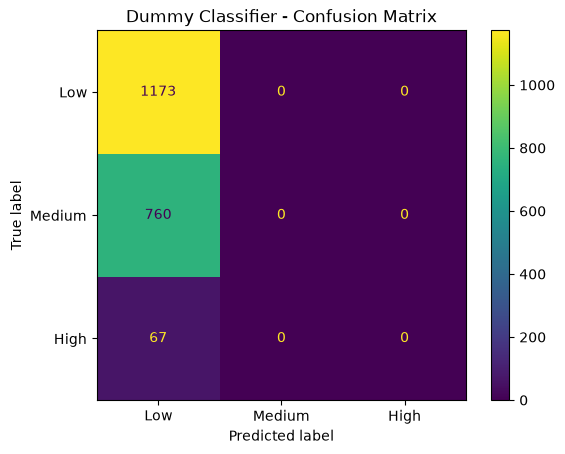

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_dummy, labels=["Low", "Medium", "High"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "Medium", "High"])
disp.plot()
plt.title("Dummy Classifier - Confusion Matrix")
plt.show()
